In [1]:
from pathlib import Path
import sys
import pickle
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

from hydrax.utils.files import get_data_path, get_img_path, mkdir
from hydrax.utils.plotting import draw_t, quat_to_yaw_manual, subsample_to_target

import seaborn as sns
import pandas as pd
sns.set(font_scale=1.7, rc={'font.size':17, 'font.family':'serif'})
img_path = get_img_path()

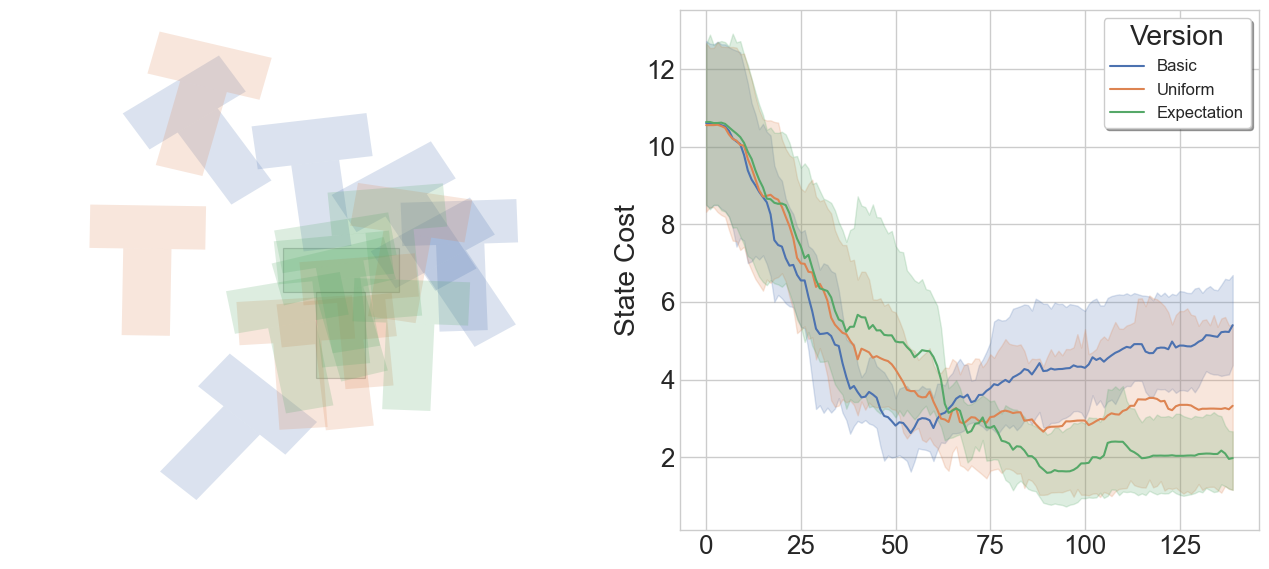

<Figure size 640x480 with 0 Axes>

In [2]:
seeds = [100, 200, 300, 400, 500, 600]
# seeds = [100]

colors = ['C0', 'C1', 'C2']

# Collect all data into long-form DataFrame
df_list = []
final_T = {}
domain_weights = {}
distances = {}

for version in ["single", "uni", "exp"]:
    final_T[version] = []
    domain_weights[version] = {}
    distances[version] = {}
    for seed in seeds:
        path = get_data_path() / "sim-real-dr-robust" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
        # path = get_data_path() / "dr_real_margin_sweep" / f"fr3_dr_real_MTP_seed{seed}_{version}.pkl"
        
        with open(path, "rb") as f:
            data = pickle.load(f)
        
        data = subsample_to_target(data, target_steps=140)  
        
        # final T
        quat = np.array(data[-1]['object_quat'])
        # quat to yaw
        jaw = quat_to_yaw_manual(quat[3], quat[0], quat[1], quat[2])
        x = data[-1]['object_pos'][0]
        y = data[-1]['object_pos'][1]
        
        # account for moved goal
        if seed == 200:
            x += 0.05
            y -= 0.1
        elif seed == 300:
            x -= 0.1
            y -= 0.05
        elif seed == 400:
            x -= 0.05
            y += 0.1
        elif seed == 500:
            x += 0.05
        elif seed == 600:
            x += 0.0
            y -= 0.05
        final_T[version].append(np.concatenate((np.array([x, y]), np.array([jaw]))))
        domain_weights[version][seed] = [data[i]['domain_weights'] for i in range(len(data))]
        distances[version][seed] = [data[i]['distances'] for i in range(len(data))]
        timestep = np.arange(min(400, len(data)))
        df_list.append(pd.DataFrame({
            'timestep': timestep,
            'terminal_error': [d["terminal_error"] for d in data[:400]],
            'version': version,
            'seed': seed
        }))



plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
df = pd.concat(df_list)
final_Ts = np.array(final_T[version]) if version in final_T else np.array([])


# plot
draw_t(axes[0], 0.0, 0.5, 0.0, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
        face_alpha=0.2, edge_width=0.9, edgecolor='black', facecolor='C2')

# draw final Ts
for version, idx in zip(["single", "uni", "exp"], range(3), strict=True):
    Ts = np.array(final_T[version]) if version in final_T else np.array([])
    for i in range(Ts.shape[0]):
        x, y, yaw = Ts[i]
        yaw = yaw - np.pi/4 + np.pi/8 
        draw_t(axes[0], -y, x, yaw, stem_w=0.05, stem_h=0.1, head_w=0.12, head_h=0.05,
            face_alpha=0.2, facecolor=colors[idx])
axes[0].set_xlim([-0.3, 0.3])
axes[0].set_ylim([0.25, 0.85])
# remove ticks
axes[0].set_xticks([])
axes[0].set_yticks([])
# remove border
for spine in axes[0].spines.values():
    spine.set_visible(False)

sns.lineplot(data=df, x='timestep', y='terminal_error', hue='version', ax=axes[1])
axes[1].set_xlabel("Planning Step")
axes[1].set_xlabel("")
axes[1].set_ylabel("State Cost")
handles, labels = axes[1].get_legend_handles_labels()
# Example mapping from old to new labels
mapping = {'single': 'Basic', 'uni': 'Uniform', 'exp': 'Expectation'}

new_labels = [mapping.get(l, l) for l in labels]
axes[1].legend(
    handles=handles,
    labels=new_labels,
    title="Version",
    loc='upper right',
    frameon=True,
    fancybox=True,
    shadow=True,
    ncol=1,
    fontsize=12
)
plt.tight_layout()
plt.show()
mkdir(f"{img_path}/fr3/dr")
plt.savefig(f"{img_path}/fr3/dr/fr3_dr_robsutness.pdf", bbox_inches='tight')